# Imports

Dataset link : https://datasetninja.com/indoor-object-detection

In [2]:
! pip install ultralytics
! pip install pycocotools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.5/719.5 kB 15.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.2/426.2 kB 10.6 MB/s eta 0:00:0000:01


In [3]:
import pycocotools
from ultralytics import YOLO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import yaml
import torch
import shutil
import wandb
import tensorflow as tf

%matplotlib inline

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

> **Now we have to declare all directories and labels**

In [4]:
root_dir="/kaggle/input/indoor-object-detection"
train_imgs_dir="/kaggle/input/indoor-object-detection/train/images"
valid_imgs_dir="/kaggle/input/indoor-object-detection/test/images"
test_imgs_dir="/kaggle/input/indoor-object-detection/test/images"

In [5]:
train_labels_dir="/kaggle/input/indoor-object-detection/train/labels"
valid_labels_dir="/kaggle/input/indoor-object-detection/test/labels"
test_labels_dir="/kaggle/input/indoor-object-detection/test/labels"

# Visualisation

In [6]:
# giving each label a number 

names={0:"door",1:"cabinetDoor",2:"refrigeratorDoor",3:"window",4:"chair",5:"table",
       6:"cabinet",7:"couch",8:"openedDoor",9:"pole"}

COLORS=np.random.uniform(0,255,(10,3))

> **This is a function to show bbox of some of our train images**

In [7]:
def show_bbox(img_name,img_dir,label_dir,axis):
    img_path=os.path.join(img_dir,img_name)
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    h,w,_=img.shape
    img=img.copy()
    
    try:
        label_path=os.path.join(label_dir,img_name[:-4]+".txt")
        label=pd.read_csv(label_path,sep=" ",header=None).values
        classes=label[:,0]
        boxes=label[:,1:]
        
        for i,box in enumerate(boxes):
            cls_id=int(classes[i])
            text=names[cls_id]
            color=COLORS[cls_id]
            xmin=int((box[0]-box[2]/2)*w)
            ymin=int((box[1]-box[3]/2)*h)
            xmax=int((box[0]+box[2]/2)*w)
            ymax=int((box[1]+box[3]/2)*h)
            cv2.rectangle(img,(xmin,ymin),(xmax,ymax),color,3)
            y=ymin-10 if ymin-10>10 else ymin+20
            cv2.putText(img,text,(xmin,y),cv2.FONT_HERSHEY_SIMPLEX,1.5,color,3)
    except:
        pass
    
    axis.imshow(img)
    axis.axis("off")

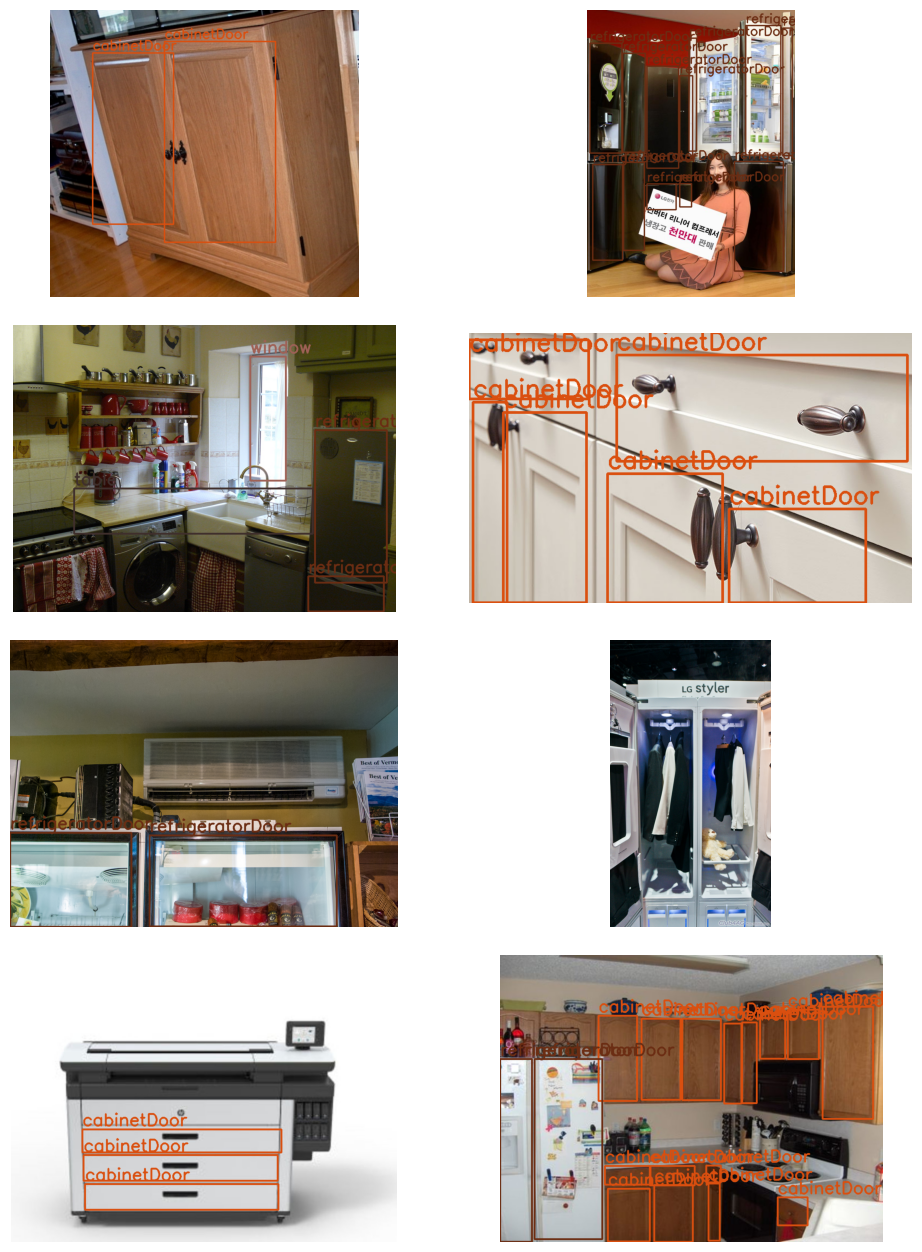

In [8]:
fig,axes=plt.subplots(4,2,figsize=(12,16))
plt.subplots_adjust(wspace=0.1,hspace=0.1)
ax=axes.flatten()


train_img_list=sorted(os.listdir(train_imgs_dir))
img_name_list=np.random.choice(train_img_list,8)


for i,img_name in enumerate(img_name_list):
    show_bbox(img_name,train_imgs_dir,train_labels_dir,ax[i])
    
plt.savefig("1.png")

# Yolo Format

The Ultralytics YOLO format is a dataset configuration format that allows you to define the dataset root directory, the relative paths to training/validation/testing image directories or *.txt files containing image paths, and a dictionary of class names.

In [9]:
yolo_format=dict(path=root_dir,
                 train=train_imgs_dir,
                 val=valid_imgs_dir,
                 nc=10,
                 names=names)
             
with open('/kaggle/working/yolo.yaml', 'w') as outfile:
    yaml.dump(yolo_format, outfile, default_flow_style=False)

# Preprocessing

# Training

In [17]:
"""Device is determined automatically. If a GPU is available then it will be used, 
   otherwise training will start on CPU."""

model=YOLO('yolov8l.pt')
model.train(data="/kaggle/working/yolo.yaml",epochs=100,patience=20,batch=32,lr0=0.0003,imgsz=640,freeze=6)

100%|██████████| 83.7M/83.7M [00:01<00:00, 82.0MB/s]


Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.0.0 CUDA:0 (Tesla P100-PCIE-16GB, 16276MiB)
engine/trainer: task=detect, mode=train, model=yolov8l.pt, data=/kaggle/working/yolo.yaml, epochs=150, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=6, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show

100%|██████████| 755k/755k [00:00<00:00, 4.07MB/s]
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/

Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytic

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

...


81 epochs completed in 1.111 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 87.7MB
Optimizer stripped from runs/detect/train/weights/best.pt, 87.6MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.0.0 CUDA:0 (Tesla P100-PCIE-16GB, 16276MiB)
Model summary (fused): 268 layers, 43614318 parameters, 0 gradients, 164.9 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.71it/s]


                   all        107        550        0.4      0.419      0.391       0.23
                  door        107         34      0.427      0.394       0.36      0.203
           cabinetDoor        107        179      0.538      0.532      0.471       0.19
      refrigeratorDoor        107          2      0.207          1      0.995      0.796
                window        107         63      0.623      0.508      0.573      0.323
                 chair        107         87      0.464      0.414       0.37      0.187
                 table        107         47      0.273      0.362      0.269      0.136
               cabinet        107         52      0.554      0.167      0.237      0.149
                 couch        107         58      0.312      0.241      0.193     0.0769
            openedDoor        107         20       0.36       0.45      0.388      0.197
                  pole        107          8      0.239      0.125     0.0575     0.0397
Speed: 1.0ms preproce

lr/pg0,▁█████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃
lr/pg1,▁█████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃
lr/pg2,▁█████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃
metrics/mAP50(B),▁▁▂▅▅▅▆▇▅▇▅▅▅▆▆▇▇█▇█▇▇▇▇▇█▇▆▇▇███▇▇█▇█▇█
metrics/mAP50-95(B),▁▁▂▅▅▅▆▆▅▆▅▅▅▆▆▇▇▇▇█▇▇▆▆▇█▇▆▇█▇██▇▇█▇▇▇█
metrics/precision(B),▁▄▆▄▄▃▇██▇▃▂▂▅▃▅▆▂▃▄▇▅▄▅▅▅▃▃▄▄▄▄▃▃▄▅█▃█▄
metrics/recall(B),▂▂▂▁▂▃▂▂▂▃▄▆▄▂▆▃▅▇▅▅▃▅▄▅▄▅▇▅▆▅▆▅█▅█▆▃▇▃▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,██▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cacdc3bac80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

# Validate

In [18]:
path_best_weights="/kaggle/working/runs/detect/train/weights/best.pt"
model = YOLO(path_best_weights) 

metrics = model.val(conf=0.20,iou=0.70) 

Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.0.0 CUDA:0 (Tesla P100-PCIE-16GB, 16276MiB)
Model summary (fused): 268 layers, 43614318 parameters, 0 gradients, 164.9 GFLOPs


val: Scanning /kaggle/input/indoor-object-detection/test/labels... 104 images, 3 backgrounds, 0 corrupt: 100%|██████████| 107/107 [00:00<00:00, 435.03it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/indoor-object-detection/test is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  1.96it/s]


                   all        107        550      0.397       0.42      0.451       0.28
                  door        107         34      0.419      0.382      0.438      0.265
           cabinetDoor        107        179      0.534      0.542      0.537      0.241
      refrigeratorDoor        107          2      0.222          1      0.995      0.801
                window        107         63      0.605      0.508      0.575      0.354
                 chair        107         87      0.461      0.414      0.458      0.249
                 table        107         47      0.267      0.362       0.31      0.171
               cabinet        107         52      0.547      0.173       0.36      0.258
                 couch        107         58      0.304      0.241      0.241      0.105
            openedDoor        107         20       0.36       0.45      0.451      0.246
                  pole        107          8       0.25      0.125      0.141      0.112
Speed: 1.8ms preproce

In [19]:
print(f"Mean Average Precision @.5:.95 : {metrics.box.map}")    
print(f"Mean Average Precision @ .50   : {metrics.box.map50}") 
print(f"Mean Average Precision @ .70   : {metrics.box.map75}")

Mean Average Precision @.5:.95 : 0.28010604119570054
Mean Average Precision @ .50   : 0.45056439268756227
Mean Average Precision @ .70   : 0.3039309086959444


In [20]:
columns=["Mean_Avg_Precision"]
cls_map=pd.DataFrame(metrics.box.maps,columns=columns,index=names.values())
cls_map.style.background_gradient(subset=columns,cmap="YlOrRd",high=0.75)

,Mean_Avg_Precision
door,0.265241
cabinetDoor,0.240723
refrigeratorDoor,0.801167
window,0.353641
chair,0.248701
table,0.171108
cabinet,0.257571
couch,0.104906
openedDoor,0.245508
pole,0.112497


# Prediction

In [21]:
with torch.no_grad():
    results=model.predict(source=test_imgs_dir,conf=0.20,iou=0.70)


image 1/107 /kaggle/input/indoor-object-detection/test/images/1003.png: 480x640 3 doors, 1 cabinetDoor, 1 table, 1 openedDoor, 75.9ms
image 2/107 /kaggle/input/indoor-object-detection/test/images/1014.png: 480x640 (no detections), 19.9ms
image 3/107 /kaggle/input/indoor-object-detection/test/images/1015.png: 480x640 (no detections), 19.9ms
image 4/107 /kaggle/input/indoor-object-detection/test/images/1020.png: 480x640 2 openedDoors, 19.9ms
image 5/107 /kaggle/input/indoor-object-detection/test/images/1021.png: 480x640 1 refrigeratorDoor, 19.9ms
image 6/107 /kaggle/input/indoor-object-detection/test/images/1023.png: 480x640 1 refrigeratorDoor, 1 window, 1 chair, 1 openedDoor, 19.9ms
image 7/107 /kaggle/input/indoor-object-detection/test/images/1026.png: 480x640 1 door, 2 windows, 1 couch, 1 openedDoor, 20.0ms
image 8/107 /kaggle/input/indoor-object-detection/test/images/1027.png: 480x640 1 chair, 1 couch, 20.0ms
image 9/107 /kaggle/input/indoor-object-detection/test/images/1028.png: 48

In [22]:
# directory for saving predictions on test dataset
!mkdir "/kaggle/working/prediction_yolo8vl"

In [23]:
prediction_dir="/kaggle/working/prediction_yolo8vl"

In [24]:
test_img_list=[]
for result in results:
    if len(result.boxes.xyxy):
        name=result.path.split("/")[-1].split(".")[0]
        boxes=result.boxes.xywhn.cpu().numpy()
        classes=result.boxes.cls.cpu().numpy()
        
        test_img_list.append(name)
        
        label_file_path=os.path.join(prediction_dir,name+".txt")
        with open(label_file_path,"w+") as f:
            for cls_obj,box in zip(classes,boxes):
                text=f"{int(cls_obj)} "+" ".join(box.astype(str))
                f.write(text)
                f.write("\n")

# Prediction Visualization

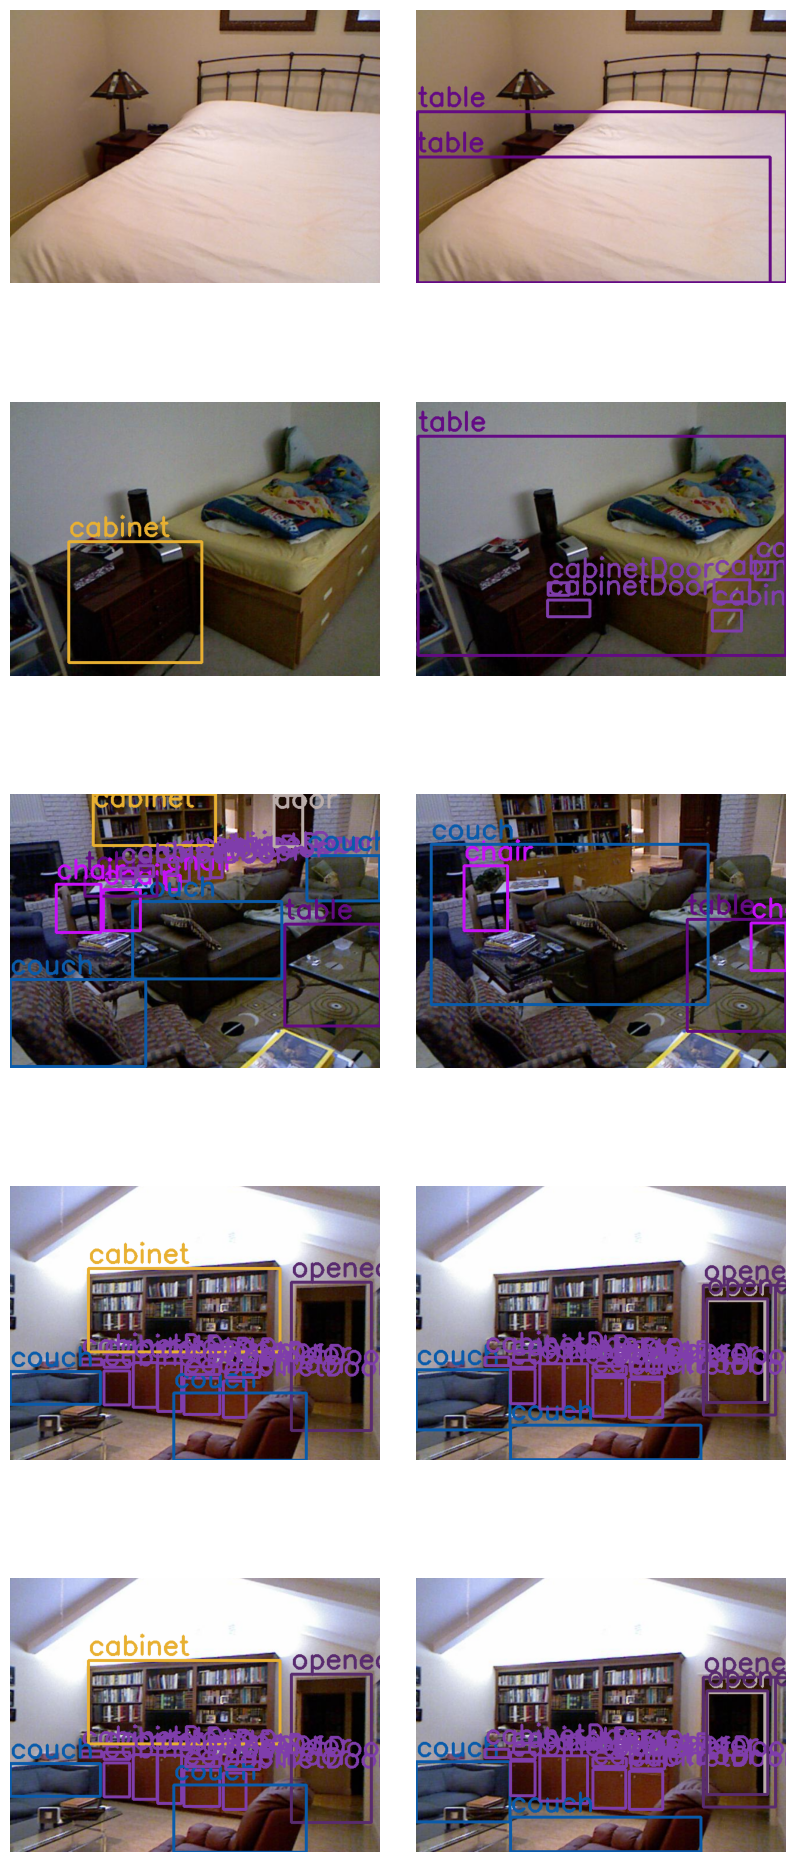

In [25]:
fig,axes=plt.subplots(5,2,figsize=(10,25))
plt.subplots_adjust(wspace=0.1,hspace=0.1)

test_img_list=list(sorted(os.listdir(test_imgs_dir)))
imgs_name=np.random.choice(test_img_list,5)

for i,img_name in enumerate(imgs_name):
    #ground truth
    show_bbox(img_name,test_imgs_dir,test_labels_dir,axis=axes[i,0])
    
    #predicted label
    show_bbox(img_name,test_imgs_dir,prediction_dir,axis=axes[i,1])
    
plt.savefig("2.png")